## Initialization

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("./plot_style.mplstyle")
from sklearn.utils.class_weight import compute_class_weight

### Import Dataset

In [2]:
MTfile =  "./outputs/dataset_MatterThread_5s.csv"
MTdata = pd.read_csv(MTfile)
MTdataA = MTdata[MTdata["File Name"] == "MatterCapture1.pcapng"]
MTdataB = MTdata[MTdata["File Name"] == "MatterCapture2.pcapng"]
MTdataC = MTdata[MTdata["File Name"] == "MatterCapture3.pcapng"]
MTdataAB = pd.concat([MTdataA, MTdataB])
MTdataAC = pd.concat([MTdataA, MTdataC])
MTdataBC = pd.concat([MTdataB, MTdataC])

ZBfile =  "./outputs/dataset_Zigbee_5s.csv"
ZBdata = pd.read_csv(ZBfile)
ZBdataA = ZBdata[ZBdata["File Name"] == "ZigbeeCapture4.pcapng"]
ZBdataB = ZBdata[ZBdata["File Name"] == "ZigbeeCapture5.pcapng"]
ZBdataC = ZBdata[ZBdata["File Name"] == "ZigbeeCapture6.pcapng"]
ZBdataAB = pd.concat([ZBdataA, ZBdataB])
ZBdataAC = pd.concat([ZBdataA, ZBdataC])
ZBdataBC = pd.concat([ZBdataB, ZBdataC])

### Define functions

In [3]:
def classify(protocol, train, test, by_category=False):
    if protocol != "MT" and protocol != "ZB":
        raise Exception("Invalid protocol. Choose either 'MT' or 'ZB'.")

    match train:
        case "ABC":
            data_train = eval(protocol + "data")
        case "A" | "B" | "C" | "AB" | "AC" | "BC":
            data_train = eval(protocol + "data" + train)
        case _:
            raise Exception("Not a valid train dataset name. Choose among A, B, C, AB, AC, BC, ABC.")
        
    match test:
        case "ABC":
            data_test = eval(protocol + "data")
        case "A" | "B" | "C" | "AB" | "AC" | "BC":
            data_test = eval(protocol + "data" + test)
        case _:
            raise Exception("Not a valid test dataset name. Choose among A, B, C, AB, AC, BC, ABC.")

    if train == test:
        X = data_test.drop(columns=["Device Name", "Device Type","File Name"])
        y = data_test["Device Type"] if by_category else data_test["Device Name"]
        y = y.astype('category')
        categories = y.cat.categories
        y = y.cat.codes
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
    
    else:
        X_train = data_train.drop(columns=["Device Name", "Device Type","File Name"])
        X_test = data_test.drop(columns=["Device Name", "Device Type","File Name"])
        y_train = data_train["Device Type"] if by_category else data_train["Device Name"]
        y_train = y_train.astype('category')
        categories = y_train.cat.categories
        y_train = y_train.cat.codes
        y_test = data_test["Device Type"] if by_category else data_test["Device Name"]
        y_test = y_test.astype('category')
        y_test = y_test.cat.codes
        class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)

    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    rf_model = RandomForestClassifier(n_jobs=-1, random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)
    actual_categories = sorted(set(y_test) | set(y_pred))
    ctarget_names = [categories[i] for i in actual_categories]

    appendix = "_g" if by_category else ""
    globals()["cm_" + protocol + "_" + train + "_" + test + appendix] = confusion_matrix(y_test, y_pred, labels=actual_categories, normalize="true")
    globals()["labels_" + protocol + "_" + train + "_" + test + appendix] = ctarget_names
    report = classification_report(y_test, y_pred, target_names=ctarget_names, labels=actual_categories, zero_division=0)
    print(report)

    f1_macro = f1_score(y_test, y_pred, average="weighted")
    print(f"Weighted F1-Score: {f1_macro:.4f}")

def print_cm(protocol, train, test, by_category=False):
    if not train in ["A", "B", "C", "AB", "AC", "BC", "ABC"]:
        raise Exception("Not a valid train dataset name. Choose among A, B, C, AB, AC, BC, ABC.")
    if not test in ["A", "B", "C", "AB", "AC", "BC", "ABC"]:
        raise Exception("Not a valid test dataset name. Choose among A, B, C, AB, AC, BC, ABC.")  
    appendix = "_g" if by_category else ""
    cm = eval("cm_" + protocol + "_" + train + "_" + test + appendix)
    plt.figure(figsize=(3, 3) if by_category else (6.2, 6.2))
    locallabel = eval("labels_" + protocol + "_" + train + "_" + test + appendix)
    ax = sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", square=1, cbar=0, xticklabels=locallabel, yticklabels=locallabel, annot_kws={"size": 10})
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=40, ha="right")
    #plt.savefig('./Plots/CM_ZB_' + train + '_' + test + appendix + '.pdf', bbox_inches='tight')
    plt.show()

# Zigbee Classification

## Dataset merged

### Matter over Thread

In [15]:
classify(protocol="MT", train="ABC", test="ABC")

                precision    recall  f1-score   support

     AqaraDoor       0.99      0.98      0.99      1399
   AqaraMotion       0.99      0.98      0.98      1549
     ESP1light       0.82      0.84      0.83     10640
     ESP2light       0.89      0.87      0.88     14540
     ESP3light       0.93      0.92      0.93      3374
    ESP4sensor       0.77      0.78      0.78      2926
    ESP5sensor       0.76      0.76      0.76      3050
    ESP6sensor       0.74      0.72      0.73      2981
  HueWhite0475       0.94      0.91      0.93      2701
  HueWhite1549       0.93      0.91      0.92      2751
  Nanoleaf0176       0.99      0.98      0.98     25788
  Nanoleaf1624       0.97      0.98      0.98     25783
Raspberry OTBR       1.00      1.00      1.00     25923

      accuracy                           0.94    123405
     macro avg       0.90      0.90      0.90    123405
  weighted avg       0.94      0.94      0.94    123405

Weighted F1-Score: 0.9384


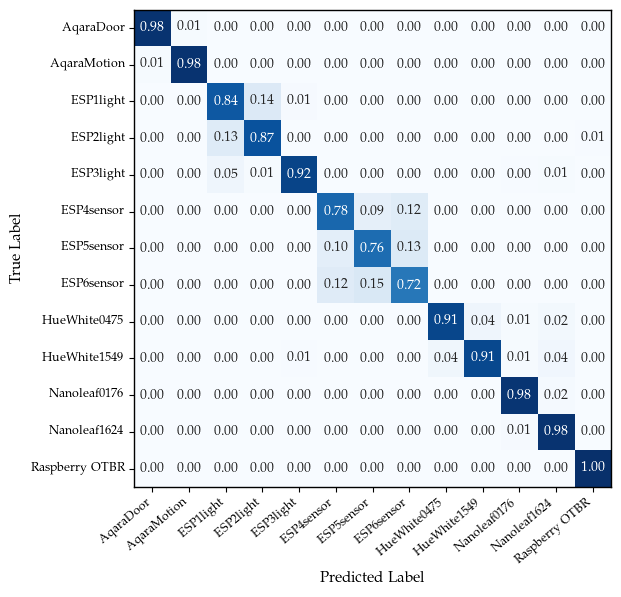

In [16]:
print_cm(protocol="MT", train="ABC", test="ABC")

### Zigbee

In [17]:
classify(protocol="ZB", train="ABC", test="ABC")

                 precision    recall  f1-score   support

    AqaraMagnet       1.00      0.98      0.99        42
 AqaraVibration       1.00      0.95      0.98        43
    ESPZB1light       0.87      0.91      0.89      1955
    ESPZB2light       0.85      0.85      0.85      1820
    ESPZB3light       0.91      0.90      0.90      4394
   ESPZB4sensor       0.94      0.91      0.92       361
   ESPZB5sensor       0.87      0.93      0.90       523
   ESPZB6sensor       0.92      0.88      0.90       561
         Hue9GF       0.87      0.88      0.87      3639
         Hue9L7       0.87      0.87      0.87      5679
   HueWhite0475       0.96      0.96      0.96     14182
   HueWhite1549       0.90      0.89      0.90      5035
Raspberry Coord       0.99      0.99      0.99     13152

       accuracy                           0.93     51386
      macro avg       0.92      0.91      0.92     51386
   weighted avg       0.93      0.93      0.93     51386

Weighted F1-Score: 0.9319


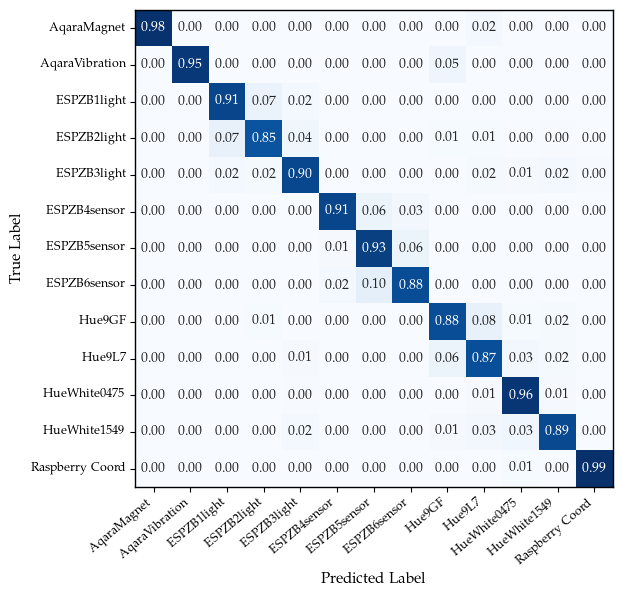

In [18]:
print_cm(protocol="ZB", train="ABC", test="ABC")

## Train A, Test B

### Matter over Thread

In [19]:
classify(train="A", test="B", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.61      0.32      0.42      2599
   AqaraMotion       0.54      0.78      0.64      2588
     ESP1light       0.01      0.00      0.00     43200
     ESP2light       0.44      0.92      0.59     16741
     ESP3light       0.14      0.32      0.19      7027
    ESP4sensor       0.52      0.43      0.47      5166
    ESP5sensor       0.40      0.50      0.44      4986
    ESP6sensor       0.36      0.32      0.34      4935
  HueWhite0475       0.34      0.22      0.27      4705
  HueWhite1549       0.22      0.23      0.23      4669
  Nanoleaf0176       0.18      0.12      0.15     43057
  Nanoleaf1624       0.57      0.46      0.51     43117
Raspberry OTBR       0.39      0.61      0.48     43136

      accuracy                           0.36    225926
     macro avg       0.36      0.40      0.36    225926
  weighted avg       0.31      0.36      0.32    225926

Weighted F1-Score: 0.3167


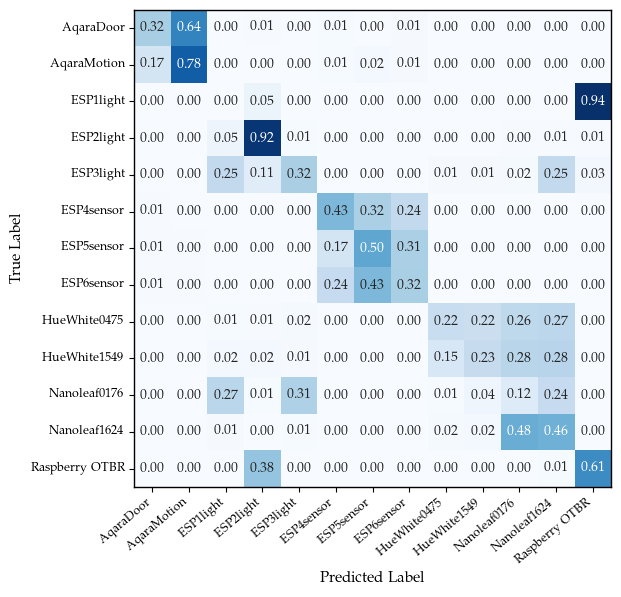

In [20]:
print_cm(train="A", test="B", protocol="MT")

### Zigbee

In [21]:
classify(train="A", test="B", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       0.76      0.79      0.77       117
 AqaraVibration       0.13      1.00      0.23        56
    ESPZB1light       0.08      0.45      0.14      3511
    ESPZB2light       0.04      0.15      0.07      3844
    ESPZB3light       0.37      0.06      0.10     17166
   ESPZB4sensor       0.06      0.11      0.08       858
   ESPZB5sensor       0.20      0.24      0.22       857
   ESPZB6sensor       0.17      0.28      0.21       847
         Hue9GF       0.22      0.43      0.29      6222
         Hue9L7       0.43      0.20      0.28      6921
   HueWhite0475       0.33      0.27      0.29     21193
   HueWhite1549       0.36      0.08      0.13     16851
Raspberry Coord       0.52      0.65      0.58     11222

       accuracy                           0.25     89665
      macro avg       0.28      0.36      0.26     89665
   weighted avg       0.34      0.25      0.24     89665

Weighted F1-Score: 0.2428


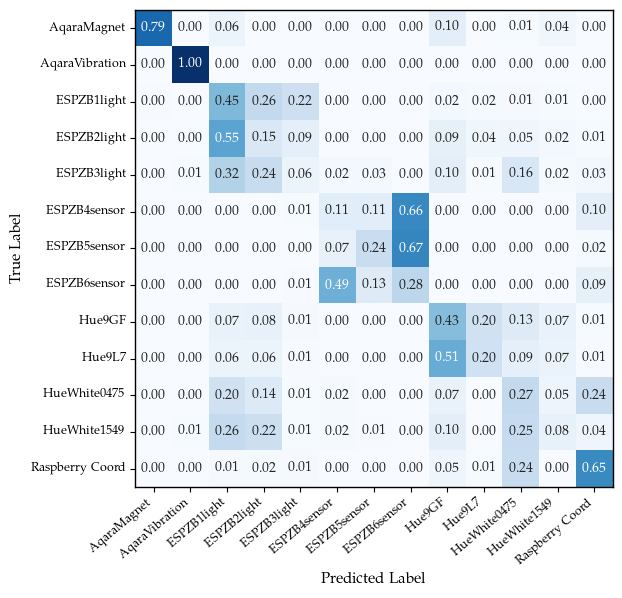

In [22]:
print_cm(train="A", test="B", protocol="ZB")

## Train A, Test C

### Matter over Thread

In [23]:
classify(train="A", test="C", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.75      0.89      0.82      2052
   AqaraMotion       0.89      0.79      0.84      2888
     ESP1light       0.14      0.48      0.21      5031
     ESP2light       0.25      0.06      0.10     43202
     ESP3light       0.11      0.36      0.17      5627
    ESP4sensor       0.47      0.46      0.46      4486
    ESP5sensor       0.41      0.51      0.46      4944
    ESP6sensor       0.37      0.29      0.32      5143
  HueWhite0475       0.34      0.24      0.28      4390
  HueWhite1549       0.27      0.29      0.28      4591
  Nanoleaf0176       0.17      0.11      0.13     43139
  Nanoleaf1624       0.62      0.51      0.56     43143
Raspberry OTBR       0.47      0.83      0.60     43197

      accuracy                           0.39    211833
     macro avg       0.40      0.45      0.40    211833
  weighted avg       0.37      0.39      0.35    211833

Weighted F1-Score: 0.3528


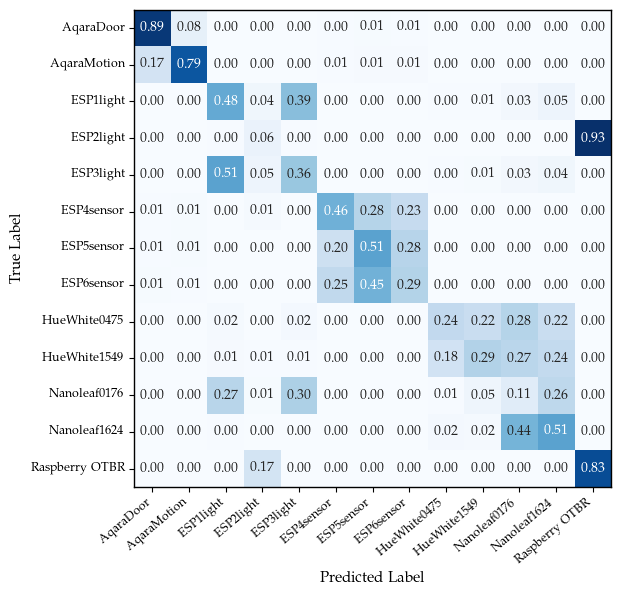

In [24]:
print_cm(train="A", test="C", protocol="MT")

### Zigbee

In [4]:
classify(train="A", test="C", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       0.86      0.87      0.86        76
 AqaraVibration       0.10      0.82      0.19        62
    ESPZB1light       0.14      0.47      0.21      2825
    ESPZB2light       0.12      0.27      0.17      2744
    ESPZB3light       0.16      0.12      0.14      2950
   ESPZB4sensor       0.02      0.08      0.04       219
   ESPZB5sensor       0.17      0.12      0.14       835
   ESPZB6sensor       0.48      0.56      0.52      1173
         Hue9GF       0.37      0.42      0.40      5827
         Hue9L7       0.14      0.02      0.04     17017
   HueWhite0475       0.21      0.06      0.09     42908
   HueWhite1549       0.36      0.16      0.22      5520
Raspberry Coord       0.13      0.58      0.22     10853

       accuracy                           0.17     93009
      macro avg       0.25      0.35      0.25     93009
   weighted avg       0.20      0.17      0.14     93009

Weighted F1-Score: 0.1385


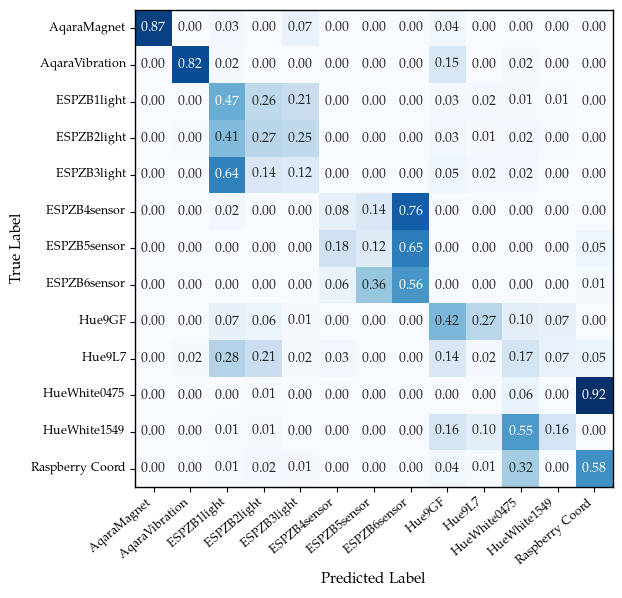

In [5]:
print_cm(train="A", test="C", protocol="ZB")

## Train B, Test A

### Matter over Thread

In [27]:
classify(train="B", test="A", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.60      0.54      0.57      2451
   AqaraMotion       0.56      0.60      0.58      2349
     ESP1light       0.00      0.00      0.00      4509
     ESP2light       0.97      0.97      0.97     12461
     ESP3light       0.47      0.95      0.63      4415
    ESP4sensor       0.52      0.66      0.58      5032
    ESP5sensor       0.46      0.46      0.46      4971
    ESP6sensor       0.36      0.25      0.29      4789
  HueWhite0475       0.27      0.32      0.29      4348
  HueWhite1549       0.27      0.29      0.28      4417
  Nanoleaf0176       0.42      0.01      0.01     43150
  Nanoleaf1624       0.48      0.93      0.63     43168
Raspberry OTBR       1.00      0.54      0.70     43202

      accuracy                           0.52    179262
     macro avg       0.49      0.50      0.46    179262
  weighted avg       0.60      0.52      0.47    179262

Weighted F1-Score: 0.4741


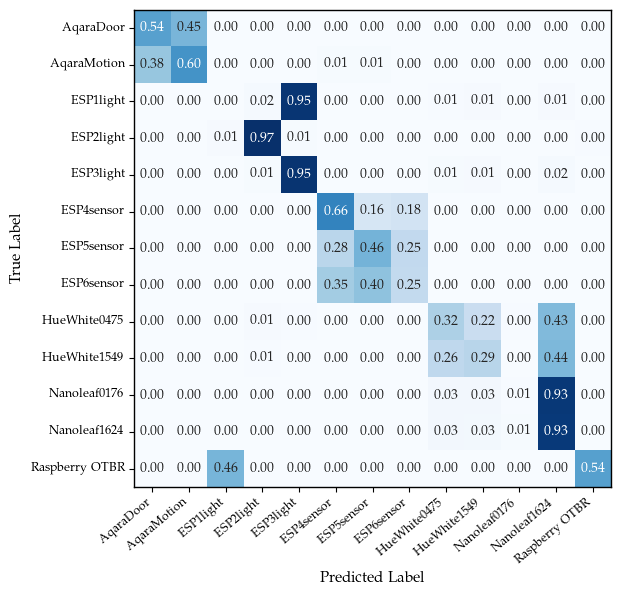

In [28]:
print_cm(train="B", test="A", protocol="MT")

### Zigbee

In [29]:
classify(train="B", test="A", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       1.00      0.97      0.99        71
 AqaraVibration       1.00      1.00      1.00        56
    ESPZB1light       0.43      0.59      0.50      3523
    ESPZB2light       0.33      0.28      0.30      2758
    ESPZB3light       0.17      0.07      0.10      2281
   ESPZB4sensor       0.46      0.03      0.06       784
   ESPZB5sensor       0.34      0.95      0.50       798
   ESPZB6sensor       0.28      0.03      0.05       785
         Hue9GF       0.30      0.25      0.27      6209
         Hue9L7       0.28      0.65      0.39      4765
   HueWhite0475       0.70      0.25      0.37      5930
   HueWhite1549       0.47      0.17      0.25      3092
Raspberry Coord       0.97      0.99      0.98     43201

       accuracy                           0.72     74253
      macro avg       0.52      0.48      0.44     74253
   weighted avg       0.74      0.72      0.71     74253

Weighted F1-Score: 0.7065


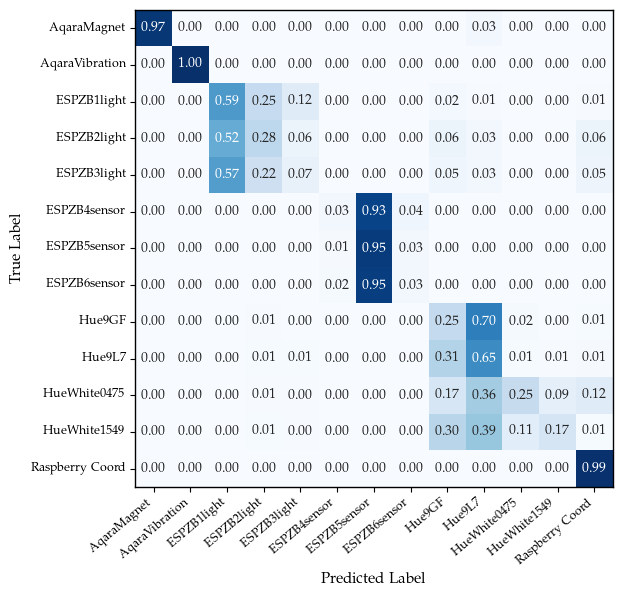

In [30]:
print_cm(train="B", test="A", protocol="ZB")

## Train B, Test C

### Matter over Thread

In [31]:
classify(train="B", test="C", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.54      0.48      0.51      2052
   AqaraMotion       0.65      0.67      0.66      2888
     ESP1light       0.00      0.00      0.00      5031
     ESP2light       0.01      0.00      0.00     43202
     ESP3light       0.34      0.39      0.36      5627
    ESP4sensor       0.45      0.56      0.50      4486
    ESP5sensor       0.44      0.45      0.45      4944
    ESP6sensor       0.39      0.30      0.34      5143
  HueWhite0475       0.33      0.31      0.32      4390
  HueWhite1549       0.30      0.24      0.27      4591
  Nanoleaf0176       0.92      0.99      0.95     43139
  Nanoleaf1624       0.89      0.87      0.88     43143
Raspberry OTBR       0.94      0.98      0.96     43197

      accuracy                           0.64    211833
     macro avg       0.48      0.48      0.48    211833
  weighted avg       0.63      0.64      0.63    211833

Weighted F1-Score: 0.6347


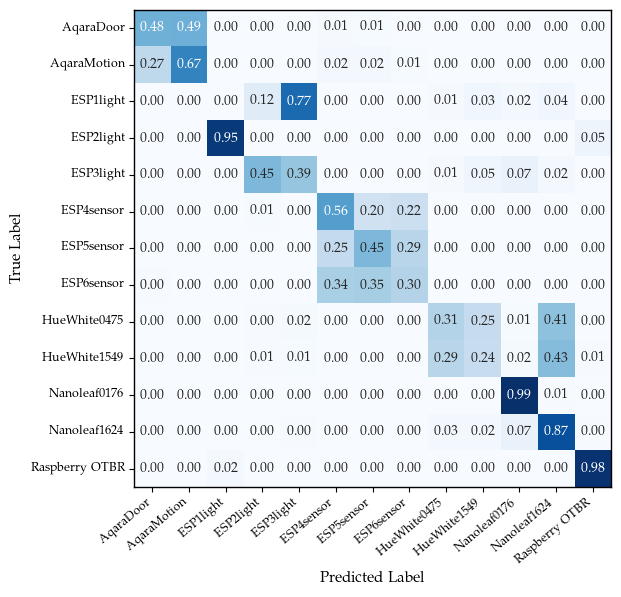

In [32]:
print_cm(train="B", test="C", protocol="MT")

### Zigbee

In [33]:
classify(train="B", test="C", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       0.89      0.92      0.90        76
 AqaraVibration       1.00      0.82      0.90        62
    ESPZB1light       0.43      0.79      0.56      2825
    ESPZB2light       0.18      0.17      0.17      2744
    ESPZB3light       0.05      0.17      0.08      2950
   ESPZB4sensor       0.83      0.72      0.77       219
   ESPZB5sensor       0.40      0.88      0.55       835
   ESPZB6sensor       0.40      0.08      0.13      1173
         Hue9GF       0.51      0.34      0.41      5827
         Hue9L7       0.11      0.04      0.06     17017
   HueWhite0475       0.42      0.16      0.23     42908
   HueWhite1549       0.10      0.10      0.10      5520
Raspberry Coord       0.24      0.93      0.39     10853

       accuracy                           0.26     93009
      macro avg       0.43      0.47      0.40     93009
   weighted avg       0.31      0.26      0.23     93009

Weighted F1-Score: 0.2296


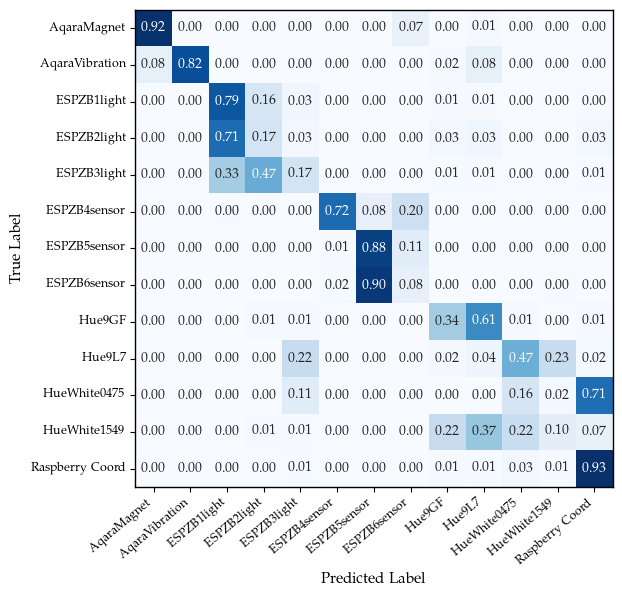

In [34]:
print_cm(train="B", test="C", protocol="ZB")

## Train C, Test A

### Matter over Thread

In [35]:
classify(train="C", test="A", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.82      0.86      0.84      2451
   AqaraMotion       0.62      0.83      0.71      2349
     ESP1light       0.29      0.70      0.41      4509
     ESP2light       0.04      0.06      0.05     12461
     ESP3light       0.25      0.36      0.29      4415
    ESP4sensor       0.53      0.58      0.55      5032
    ESP5sensor       0.46      0.41      0.43      4971
    ESP6sensor       0.36      0.38      0.37      4789
  HueWhite0475       0.26      0.29      0.27      4348
  HueWhite1549       0.28      0.32      0.30      4417
  Nanoleaf0176       0.32      0.00      0.00     43150
  Nanoleaf1624       0.47      0.94      0.63     43168
Raspberry OTBR       0.98      0.66      0.79     43202

      accuracy                           0.49    179262
     macro avg       0.44      0.49      0.43    179262
  weighted avg       0.51      0.49      0.44    179262

Weighted F1-Score: 0.4351


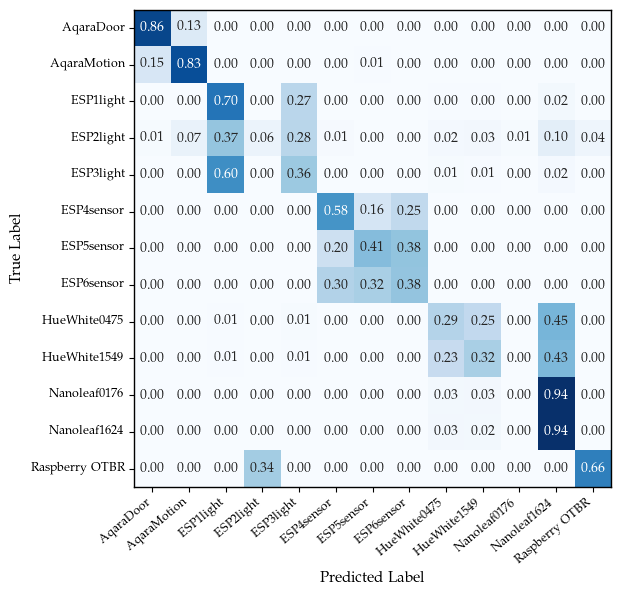

In [36]:
print_cm(train="C", test="A", protocol="MT")

### Zigbee

In [37]:
classify(train="C", test="A", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       0.98      0.87      0.93        71
 AqaraVibration       1.00      1.00      1.00        56
    ESPZB1light       0.45      0.25      0.32      3523
    ESPZB2light       0.38      0.54      0.44      2758
    ESPZB3light       0.17      0.16      0.16      2281
   ESPZB4sensor       0.51      0.03      0.06       784
   ESPZB5sensor       0.35      0.23      0.27       798
   ESPZB6sensor       0.33      0.75      0.46       785
         Hue9GF       0.45      0.75      0.56      6209
         Hue9L7       0.24      0.02      0.04      4765
   HueWhite0475       0.00      0.01      0.00      5930
   HueWhite1549       0.22      0.67      0.34      3092
Raspberry Coord       0.98      0.49      0.65     43201

       accuracy                           0.43     74253
      macro avg       0.47      0.44      0.40     74253
   weighted avg       0.69      0.43      0.49     74253

Weighted F1-Score: 0.4903


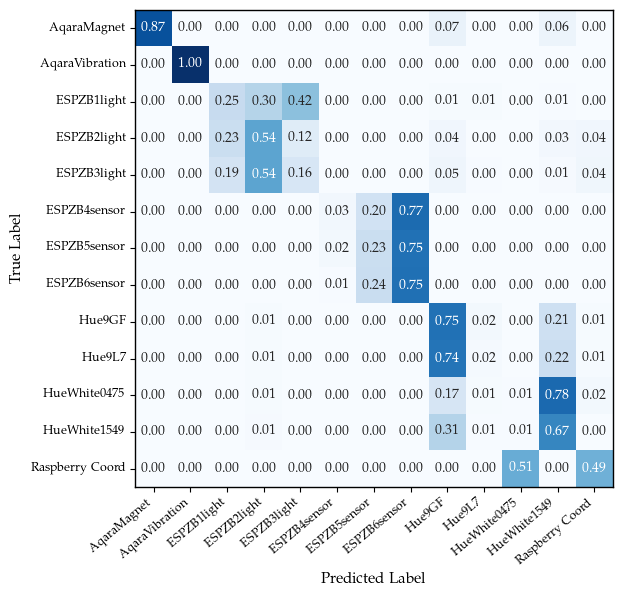

In [38]:
print_cm(train="C", test="A", protocol="ZB")

## Train C, Test B

### Matter over Thread

In [39]:
classify(train="C", test="B", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.59      0.28      0.38      2599
   AqaraMotion       0.45      0.84      0.58      2588
     ESP1light       0.00      0.00      0.00     43200
     ESP2light       0.02      0.04      0.02     16741
     ESP3light       0.28      0.25      0.26      7027
    ESP4sensor       0.50      0.50      0.50      5166
    ESP5sensor       0.43      0.44      0.44      4986
    ESP6sensor       0.35      0.38      0.37      4935
  HueWhite0475       0.32      0.28      0.30      4705
  HueWhite1549       0.26      0.22      0.24      4669
  Nanoleaf0176       0.94      0.97      0.95     43057
  Nanoleaf1624       0.84      0.91      0.87     43117
Raspberry OTBR       0.97      0.99      0.98     43136

      accuracy                           0.61    225926
     macro avg       0.46      0.47      0.45    225926
  weighted avg       0.59      0.61      0.60    225926

Weighted F1-Score: 0.5965


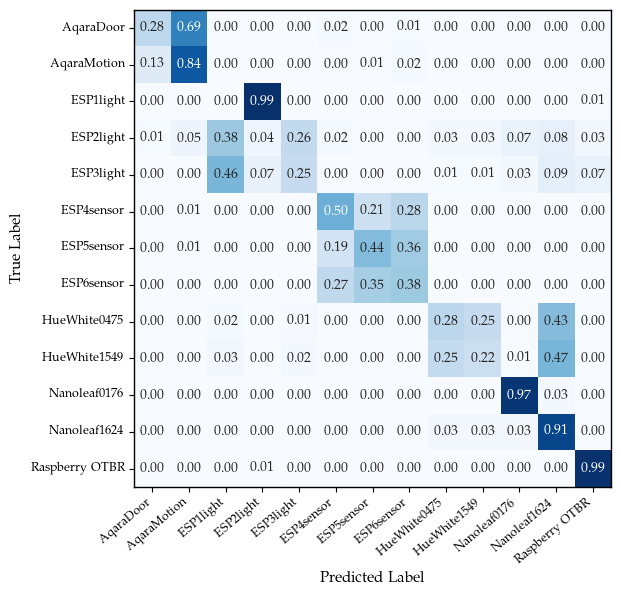

In [40]:
print_cm(train="C", test="B", protocol="MT")

### Zigbee

In [41]:
classify(train="C", test="B", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       1.00      0.62      0.77       117
 AqaraVibration       0.96      0.98      0.97        56
    ESPZB1light       0.21      0.48      0.29      3511
    ESPZB2light       0.33      0.24      0.27      3844
    ESPZB3light       0.30      0.09      0.14     17166
   ESPZB4sensor       0.64      0.05      0.09       858
   ESPZB5sensor       0.37      0.37      0.37       857
   ESPZB6sensor       0.30      0.57      0.39       847
         Hue9GF       0.43      0.65      0.52      6222
         Hue9L7       0.03      0.17      0.05      6921
   HueWhite0475       0.55      0.22      0.31     21193
   HueWhite1549       0.07      0.02      0.03     16851
Raspberry Coord       0.79      0.89      0.84     11222

       accuracy                           0.28     89665
      macro avg       0.46      0.41      0.39     89665
   weighted avg       0.37      0.28      0.28     89665

Weighted F1-Score: 0.2840


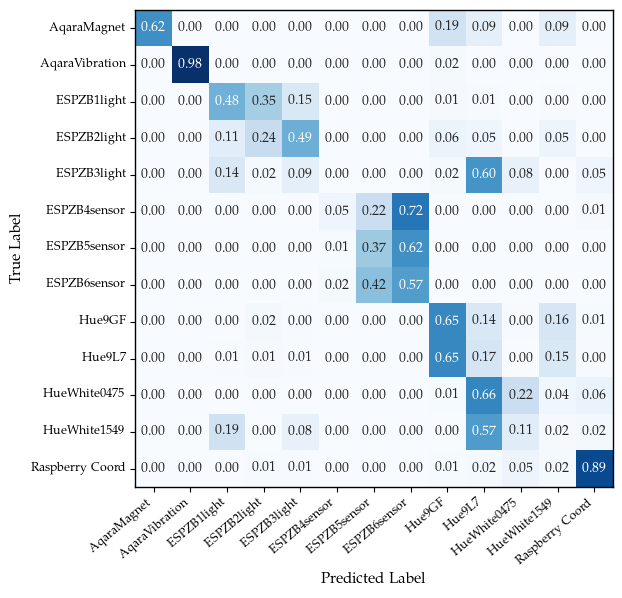

In [42]:
print_cm(train="C", test="B", protocol="ZB")

## Train A, Test A

### Matter over Thread

In [43]:
classify(train="A", test="A", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       1.00      0.98      0.99       496
   AqaraMotion       0.98      0.99      0.99       470
     ESP1light       0.91      0.92      0.91       866
     ESP2light       0.99      1.00      0.99      2421
     ESP3light       0.92      0.90      0.91       847
    ESP4sensor       0.77      0.80      0.78      1055
    ESP5sensor       0.75      0.76      0.76      1007
    ESP6sensor       0.76      0.72      0.74       927
  HueWhite0475       0.95      0.92      0.94       904
  HueWhite1549       0.95      0.94      0.94       871
  Nanoleaf0176       0.97      0.97      0.97      8646
  Nanoleaf1624       0.96      0.97      0.97      8574
Raspberry OTBR       1.00      1.00      1.00      8769

      accuracy                           0.96     35853
     macro avg       0.92      0.91      0.91     35853
  weighted avg       0.96      0.96      0.96     35853

Weighted F1-Score: 0.9565


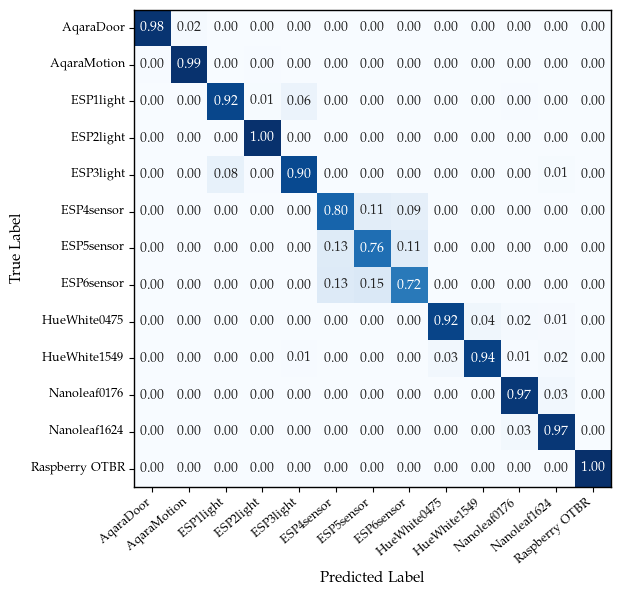

In [44]:
print_cm(train="A", test="A", protocol="MT")

### Zigbee

In [45]:
classify(train="A", test="A", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       1.00      1.00      1.00         9
 AqaraVibration       1.00      1.00      1.00        11
    ESPZB1light       0.93      0.94      0.94       697
    ESPZB2light       0.84      0.86      0.85       554
    ESPZB3light       0.84      0.84      0.84       449
   ESPZB4sensor       0.95      0.93      0.94       162
   ESPZB5sensor       0.91      0.92      0.91       160
   ESPZB6sensor       0.88      0.88      0.88       145
         Hue9GF       0.86      0.86      0.86      1243
         Hue9L7       0.82      0.83      0.83       910
   HueWhite0475       0.89      0.89      0.89      1181
   HueWhite1549       0.89      0.85      0.87       625
Raspberry Coord       1.00      1.00      1.00      8705

       accuracy                           0.95     14851
      macro avg       0.91      0.91      0.91     14851
   weighted avg       0.95      0.95      0.95     14851

Weighted F1-Score: 0.9475


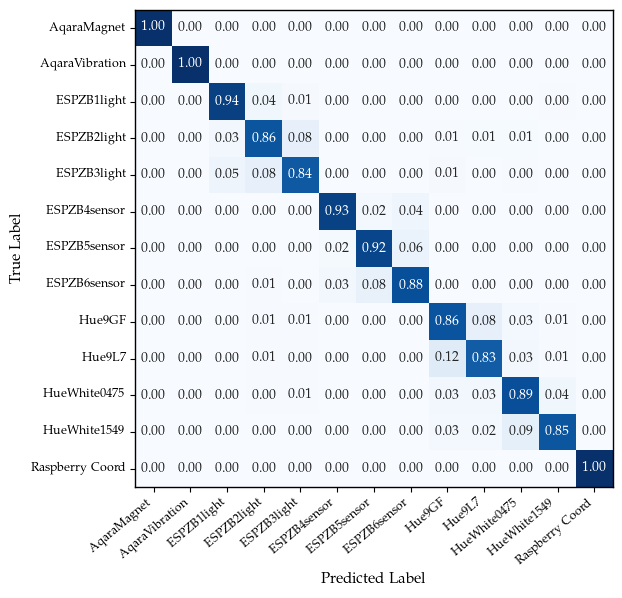

In [46]:
print_cm(train="A", test="A", protocol="ZB")

## Train B, Test B

### Matter over Thread

In [47]:
classify(train="B", test="B", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.99      0.98      0.98       557
   AqaraMotion       0.97      0.98      0.97       472
     ESP1light       1.00      1.00      1.00      8607
     ESP2light       0.99      0.99      0.99      3261
     ESP3light       0.97      0.98      0.97      1394
    ESP4sensor       0.78      0.79      0.78      1057
    ESP5sensor       0.76      0.74      0.75       991
    ESP6sensor       0.71      0.71      0.71       927
  HueWhite0475       0.93      0.89      0.91       937
  HueWhite1549       0.92      0.90      0.91       920
  Nanoleaf0176       0.99      1.00      0.99      8631
  Nanoleaf1624       0.99      0.99      0.99      8696
Raspberry OTBR       1.00      1.00      1.00      8736

      accuracy                           0.97     45186
     macro avg       0.92      0.92      0.92     45186
  weighted avg       0.97      0.97      0.97     45186

Weighted F1-Score: 0.9728


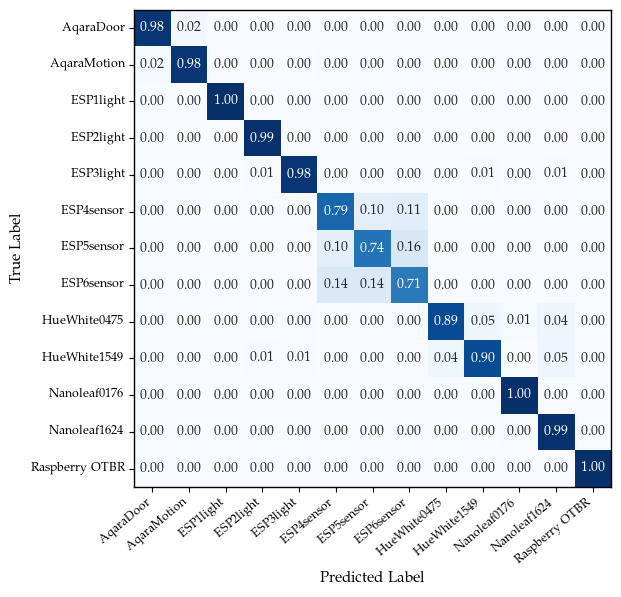

In [48]:
print_cm(train="B", test="B", protocol="MT")

### Zigbee

In [4]:
classify(train="B", test="B", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       0.87      1.00      0.93        13
 AqaraVibration       1.00      1.00      1.00        14
    ESPZB1light       0.97      0.94      0.95       711
    ESPZB2light       0.91      0.93      0.92       747
    ESPZB3light       0.92      0.93      0.92      3427
   ESPZB4sensor       0.98      0.89      0.93       166
   ESPZB5sensor       0.87      0.97      0.92       177
   ESPZB6sensor       0.95      0.93      0.94       165
         Hue9GF       0.87      0.84      0.86      1261
         Hue9L7       0.87      0.88      0.88      1423
   HueWhite0475       0.94      0.94      0.94      4225
   HueWhite1549       0.92      0.90      0.91      3329
Raspberry Coord       0.97      0.97      0.97      2275

       accuracy                           0.92     17933
      macro avg       0.93      0.93      0.93     17933
   weighted avg       0.92      0.92      0.92     17933

Weighted F1-Score: 0.9239


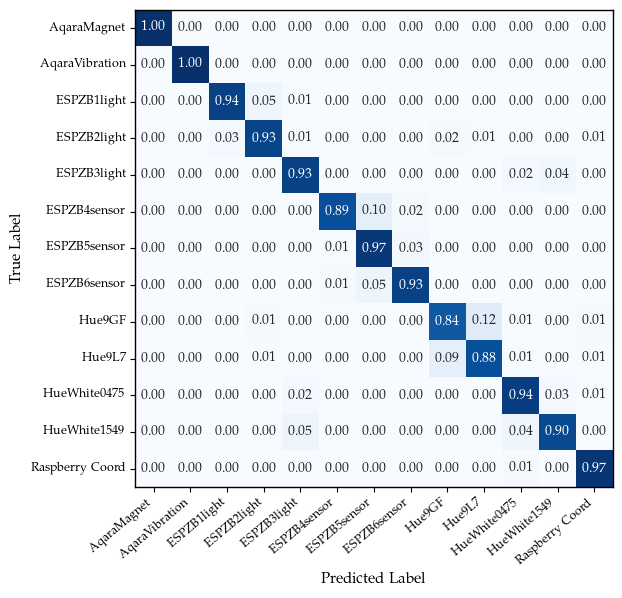

In [5]:
print_cm(train="B", test="B", protocol="ZB")

## Train C, Test C

### Matter over Thread

In [51]:
classify(train="C", test="C", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.99      0.99      0.99       438
   AqaraMotion       0.98      0.98      0.98       527
     ESP1light       0.92      0.92      0.92       994
     ESP2light       0.99      1.00      0.99      8633
     ESP3light       0.93      0.93      0.93      1075
    ESP4sensor       0.81      0.82      0.82       889
    ESP5sensor       0.76      0.80      0.78       986
    ESP6sensor       0.79      0.75      0.77      1035
  HueWhite0475       0.94      0.92      0.93       844
  HueWhite1549       0.93      0.92      0.92       926
  Nanoleaf0176       1.00      1.00      1.00      8721
  Nanoleaf1624       0.99      0.99      0.99      8643
Raspberry OTBR       0.99      0.99      0.99      8656

      accuracy                           0.97     42367
     macro avg       0.93      0.92      0.92     42367
  weighted avg       0.97      0.97      0.97     42367

Weighted F1-Score: 0.9734


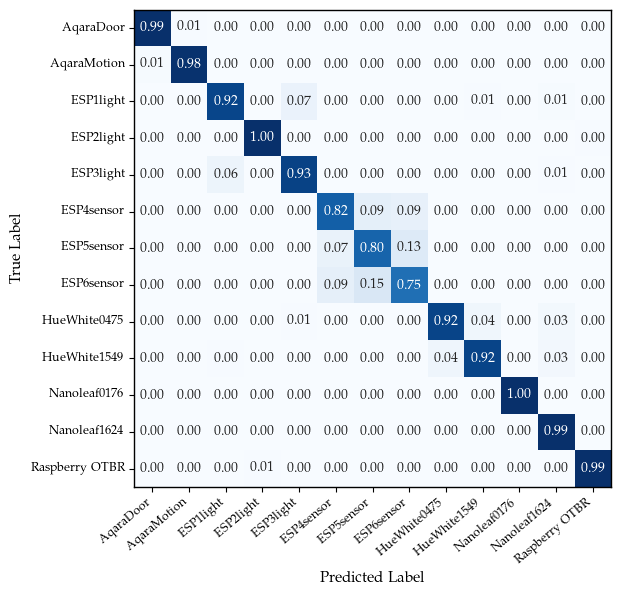

In [52]:
print_cm(train="C", test="C", protocol="MT")

### Zigbee

In [53]:
classify(train="C", test="C", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       1.00      1.00      1.00         3
 AqaraVibration       1.00      1.00      1.00        15
    ESPZB1light       0.83      0.81      0.82       559
    ESPZB2light       0.82      0.82      0.82       514
    ESPZB3light       0.88      0.89      0.88       609
   ESPZB4sensor       0.98      0.91      0.94        46
   ESPZB5sensor       0.93      0.86      0.90       166
   ESPZB6sensor       0.90      0.96      0.93       236
         Hue9GF       0.93      0.93      0.93      1160
         Hue9L7       0.98      0.99      0.98      3430
   HueWhite0475       0.99      1.00      0.99      8688
   HueWhite1549       0.93      0.94      0.93      1058
Raspberry Coord       0.98      0.96      0.97      2118

       accuracy                           0.97     18602
      macro avg       0.93      0.93      0.93     18602
   weighted avg       0.97      0.97      0.97     18602

Weighted F1-Score: 0.9665


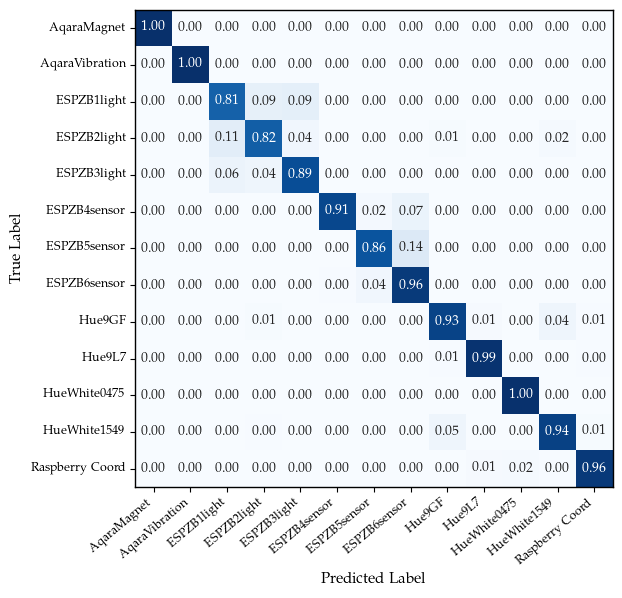

In [54]:
print_cm(train="C", test="C", protocol="ZB")

## Train A, Test BC

### Matter over Thread

In [55]:
classify(train="A", test="BC", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.70      0.58      0.63      4651
   AqaraMotion       0.68      0.78      0.73      5476
     ESP1light       0.08      0.05      0.06     48231
     ESP2light       0.39      0.30      0.34     59943
     ESP3light       0.13      0.34      0.18     12654
    ESP4sensor       0.49      0.44      0.47      9652
    ESP5sensor       0.40      0.51      0.45      9930
    ESP6sensor       0.36      0.30      0.33     10078
  HueWhite0475       0.34      0.23      0.28      9095
  HueWhite1549       0.24      0.26      0.25      9260
  Nanoleaf0176       0.18      0.11      0.14     86196
  Nanoleaf1624       0.59      0.49      0.53     86260
Raspberry OTBR       0.43      0.72      0.54     86333

      accuracy                           0.37    437759
     macro avg       0.39      0.39      0.38    437759
  weighted avg       0.36      0.37      0.35    437759

Weighted F1-Score: 0.3531


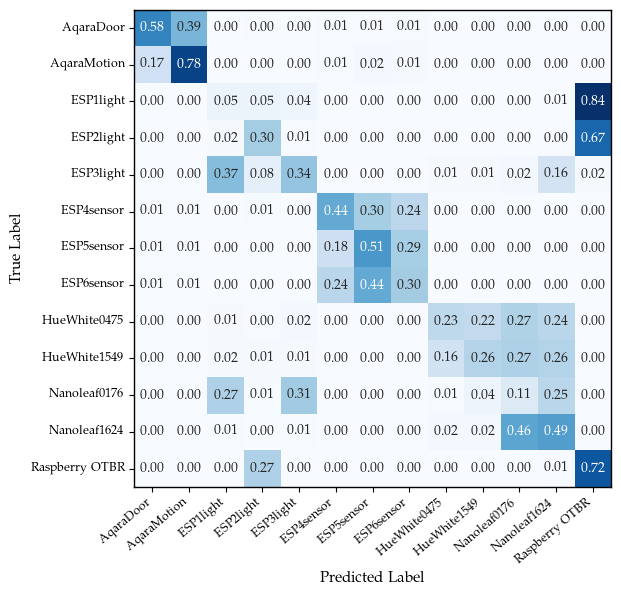

In [56]:
print_cm(train="A", test="BC", protocol="MT")

### Zigbee

In [57]:
classify(train="A", test="BC", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       0.80      0.82      0.81       193
 AqaraVibration       0.12      0.91      0.21       118
    ESPZB1light       0.10      0.46      0.17      6336
    ESPZB2light       0.07      0.20      0.10      6588
    ESPZB3light       0.28      0.07      0.11     20116
   ESPZB4sensor       0.05      0.11      0.07      1077
   ESPZB5sensor       0.19      0.18      0.18      1692
   ESPZB6sensor       0.32      0.44      0.38      2020
         Hue9GF       0.27      0.43      0.33     12049
         Hue9L7       0.30      0.07      0.12     23938
   HueWhite0475       0.28      0.13      0.18     64101
   HueWhite1549       0.36      0.10      0.16     22371
Raspberry Coord       0.22      0.62      0.33     22075

       accuracy                           0.21    182674
      macro avg       0.26      0.35      0.24    182674
   weighted avg       0.27      0.21      0.19    182674

Weighted F1-Score: 0.1874


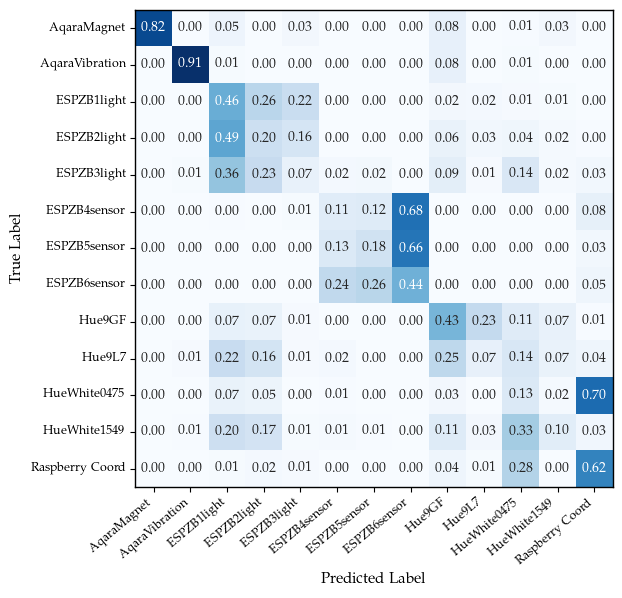

In [58]:
print_cm(train="A", test="BC", protocol="ZB")

## Train BC, Test A

### Matter over Thread

In [59]:
classify(train="BC", test="A", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.76      0.87      0.81      2451
   AqaraMotion       0.84      0.71      0.77      2349
     ESP1light       0.39      0.39      0.39      4509
     ESP2light       0.56      0.97      0.71     12461
     ESP3light       0.49      0.66      0.56      4415
    ESP4sensor       0.56      0.64      0.60      5032
    ESP5sensor       0.47      0.47      0.47      4971
    ESP6sensor       0.36      0.31      0.33      4789
  HueWhite0475       0.28      0.31      0.29      4348
  HueWhite1549       0.30      0.33      0.31      4417
  Nanoleaf0176       0.42      0.00      0.01     43150
  Nanoleaf1624       0.48      0.94      0.63     43168
Raspberry OTBR       1.00      0.76      0.86     43202

      accuracy                           0.58    179262
     macro avg       0.53      0.56      0.52    179262
  weighted avg       0.59      0.58      0.51    179262

Weighted F1-Score: 0.5089


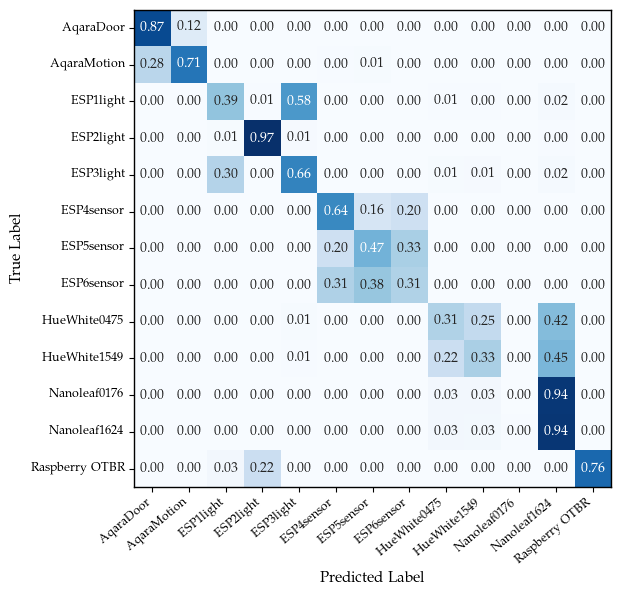

In [60]:
print_cm(train="BC", test="A", protocol="MT")

### Zigbee

In [61]:
classify(train="BC", test="A", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       1.00      0.97      0.99        71
 AqaraVibration       1.00      1.00      1.00        56
    ESPZB1light       0.49      0.35      0.41      3523
    ESPZB2light       0.39      0.55      0.45      2758
    ESPZB3light       0.13      0.09      0.11      2281
   ESPZB4sensor       0.56      0.04      0.07       784
   ESPZB5sensor       0.29      0.46      0.35       798
   ESPZB6sensor       0.33      0.44      0.38       785
         Hue9GF       0.39      0.54      0.45      6209
         Hue9L7       0.29      0.26      0.28      4765
   HueWhite0475       0.01      0.03      0.02      5930
   HueWhite1549       0.24      0.53      0.33      3092
Raspberry Coord       0.98      0.74      0.84     43201

       accuracy                           0.57     74253
      macro avg       0.47      0.46      0.44     74253
   weighted avg       0.69      0.57      0.61     74253

Weighted F1-Score: 0.6107


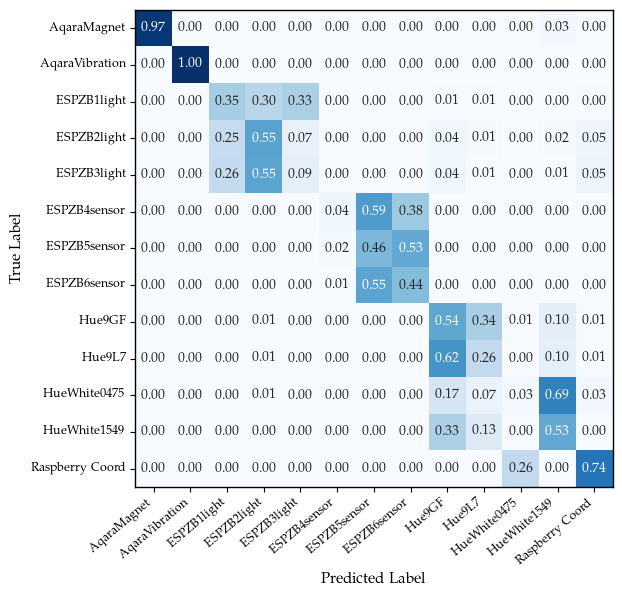

In [62]:
print_cm(train="BC", test="A", protocol="ZB")

## Train B, Test AC

### Matter over Thread

In [63]:
classify(train="B", test="AC", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.57      0.51      0.54      4503
   AqaraMotion       0.61      0.64      0.62      5237
     ESP1light       0.00      0.00      0.00      9540
     ESP2light       0.77      0.22      0.34     55663
     ESP3light       0.42      0.64      0.50     10042
    ESP4sensor       0.49      0.61      0.54      9518
    ESP5sensor       0.45      0.46      0.45      9915
    ESP6sensor       0.37      0.28      0.32      9932
  HueWhite0475       0.30      0.31      0.31      8738
  HueWhite1549       0.28      0.26      0.27      9008
  Nanoleaf0176       0.91      0.50      0.64     86289
  Nanoleaf1624       0.61      0.90      0.73     86311
Raspberry OTBR       0.96      0.76      0.85     86399

      accuracy                           0.58    391095
     macro avg       0.52      0.47      0.47    391095
  weighted avg       0.73      0.58      0.61    391095

Weighted F1-Score: 0.6125


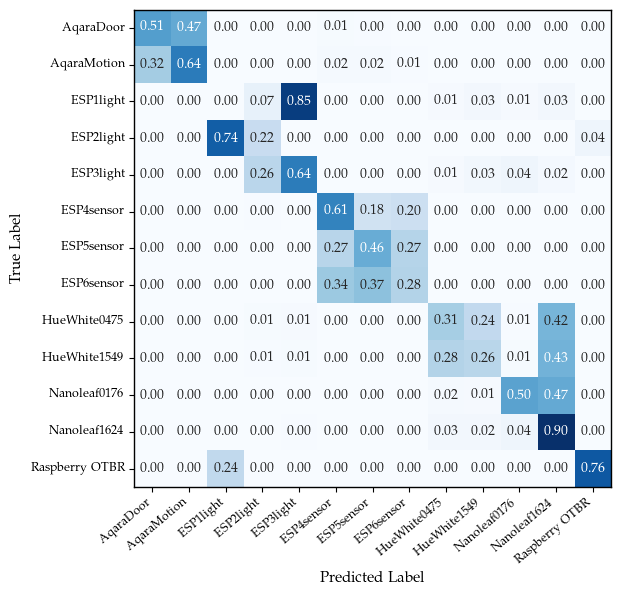

In [64]:
print_cm(train="B", test="AC", protocol="MT")

### Zigbee

In [65]:
classify(train="B", test="AC", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       0.94      0.95      0.94       147
 AqaraVibration       1.00      0.91      0.95       118
    ESPZB1light       0.43      0.68      0.53      6348
    ESPZB2light       0.25      0.22      0.24      5502
    ESPZB3light       0.07      0.13      0.09      5231
   ESPZB4sensor       0.75      0.18      0.29      1003
   ESPZB5sensor       0.37      0.91      0.53      1633
   ESPZB6sensor       0.37      0.06      0.10      1958
         Hue9GF       0.39      0.29      0.33     12036
         Hue9L7       0.22      0.17      0.19     21782
   HueWhite0475       0.45      0.17      0.25     48838
   HueWhite1549       0.16      0.12      0.14      8612
Raspberry Coord       0.62      0.98      0.76     54054

       accuracy                           0.47    167262
      macro avg       0.46      0.45      0.41    167262
   weighted avg       0.44      0.47      0.42    167262

Weighted F1-Score: 0.4150


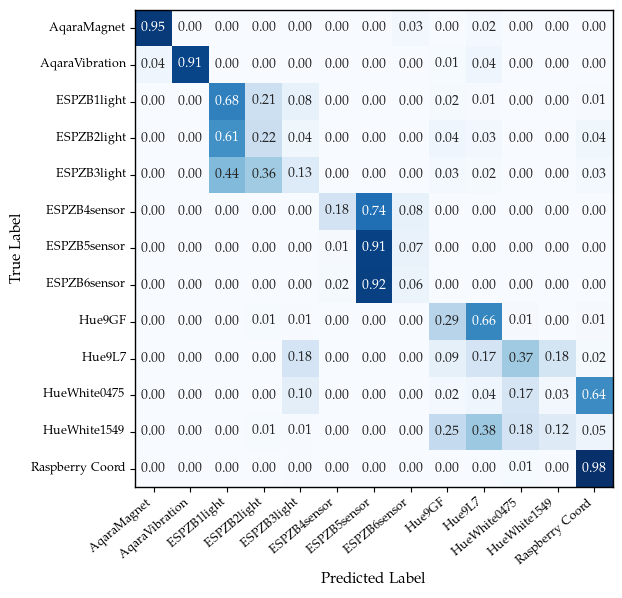

In [66]:
print_cm(train="B", test="AC", protocol="ZB")

## Train AC, Test B

### Matter over Thread

In [67]:
classify(train="AC", test="B", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.68      0.29      0.41      2599
   AqaraMotion       0.54      0.85      0.66      2588
     ESP1light       0.00      0.00      0.00     43200
     ESP2light       0.23      0.79      0.36     16741
     ESP3light       0.49      0.29      0.36      7027
    ESP4sensor       0.55      0.54      0.54      5166
    ESP5sensor       0.45      0.49      0.47      4986
    ESP6sensor       0.37      0.35      0.36      4935
  HueWhite0475       0.37      0.25      0.30      4705
  HueWhite1549       0.32      0.24      0.28      4669
  Nanoleaf0176       0.74      0.97      0.84     43057
  Nanoleaf1624       0.84      0.66      0.74     43117
Raspberry OTBR       0.98      0.99      0.98     43136

      accuracy                           0.62    225926
     macro avg       0.51      0.52      0.48    225926
  weighted avg       0.58      0.62      0.58    225926

Weighted F1-Score: 0.5821


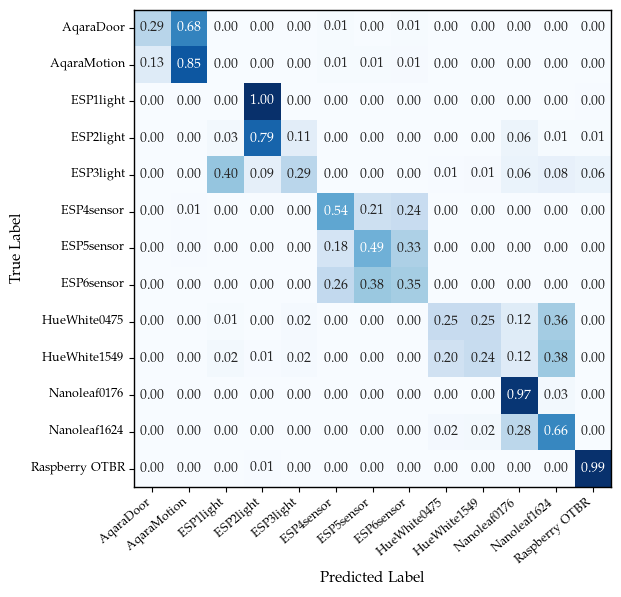

In [68]:
print_cm(train="AC", test="B", protocol="MT")

### Zigbee

In [69]:
classify(train="AC", test="B", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       1.00      0.79      0.89       117
 AqaraVibration       0.96      0.98      0.97        56
    ESPZB1light       0.20      0.50      0.29      3511
    ESPZB2light       0.27      0.19      0.22      3844
    ESPZB3light       0.28      0.09      0.14     17166
   ESPZB4sensor       0.48      0.04      0.07       858
   ESPZB5sensor       0.38      0.41      0.39       857
   ESPZB6sensor       0.29      0.52      0.37       847
         Hue9GF       0.43      0.57      0.49      6222
         Hue9L7       0.05      0.24      0.08      6921
   HueWhite0475       0.52      0.25      0.34     21193
   HueWhite1549       0.07      0.01      0.02     16851
Raspberry Coord       0.78      0.88      0.82     11222

       accuracy                           0.28     89665
      macro avg       0.44      0.42      0.39     89665
   weighted avg       0.35      0.28      0.28     89665

Weighted F1-Score: 0.2821


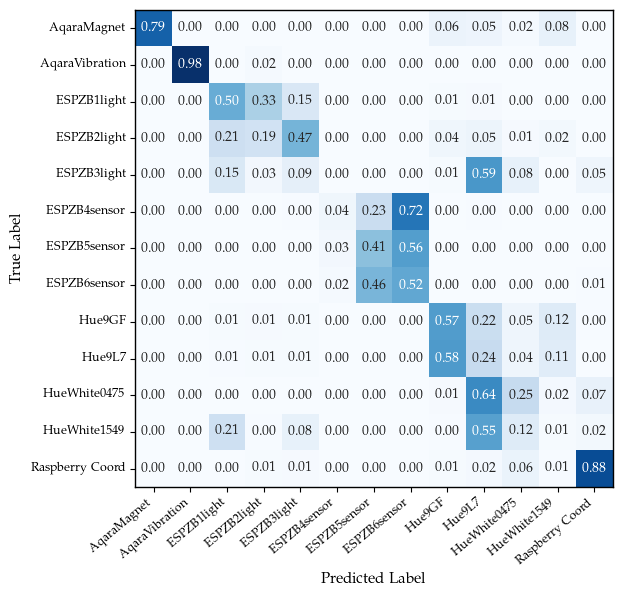

In [70]:
print_cm(train="AC", test="B", protocol="ZB")

## Train C, Test AB

### Matter over Thread

In [71]:
classify(train="C", test="AB", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.74      0.56      0.64      5050
   AqaraMotion       0.51      0.84      0.64      4937
     ESP1light       0.15      0.07      0.09     47709
     ESP2light       0.02      0.05      0.03     29202
     ESP3light       0.26      0.29      0.28     11442
    ESP4sensor       0.51      0.54      0.52     10198
    ESP5sensor       0.44      0.43      0.44      9957
    ESP6sensor       0.36      0.38      0.37      9724
  HueWhite0475       0.29      0.29      0.29      9053
  HueWhite1549       0.27      0.27      0.27      9086
  Nanoleaf0176       0.93      0.48      0.64     86207
  Nanoleaf1624       0.60      0.93      0.73     86285
Raspberry OTBR       0.97      0.82      0.89     86338

      accuracy                           0.56    405188
     macro avg       0.47      0.46      0.45    405188
  weighted avg       0.62      0.56      0.56    405188

Weighted F1-Score: 0.5628


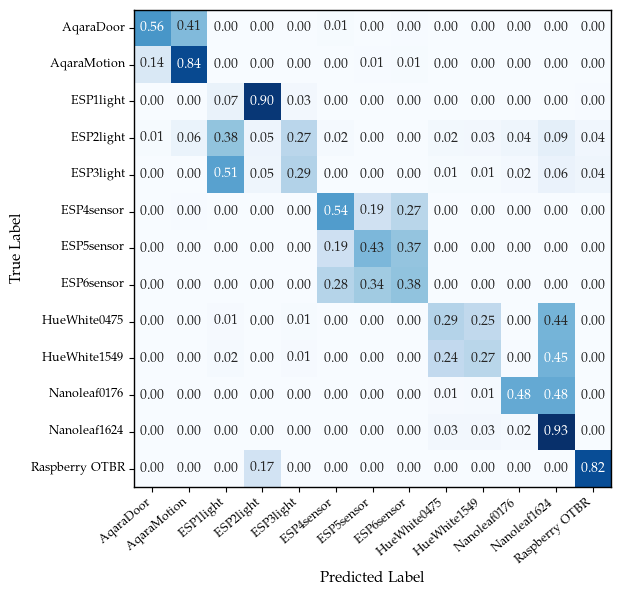

In [72]:
print_cm(train="C", test="AB", protocol="MT")

### Zigbee

In [73]:
classify(train="C", test="AB", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       0.99      0.72      0.83       188
 AqaraVibration       0.98      0.99      0.99       112
    ESPZB1light       0.26      0.36      0.30      7034
    ESPZB2light       0.36      0.37      0.36      6602
    ESPZB3light       0.26      0.10      0.15     19447
   ESPZB4sensor       0.58      0.04      0.08      1642
   ESPZB5sensor       0.36      0.30      0.33      1655
   ESPZB6sensor       0.31      0.66      0.42      1632
         Hue9GF       0.44      0.70      0.54     12431
         Hue9L7       0.03      0.11      0.05     11686
   HueWhite0475       0.15      0.17      0.16     27123
   HueWhite1549       0.18      0.12      0.14     19943
Raspberry Coord       0.91      0.57      0.70     54423

       accuracy                           0.35    163918
      macro avg       0.45      0.40      0.39    163918
   weighted avg       0.46      0.35      0.38    163918

Weighted F1-Score: 0.3769


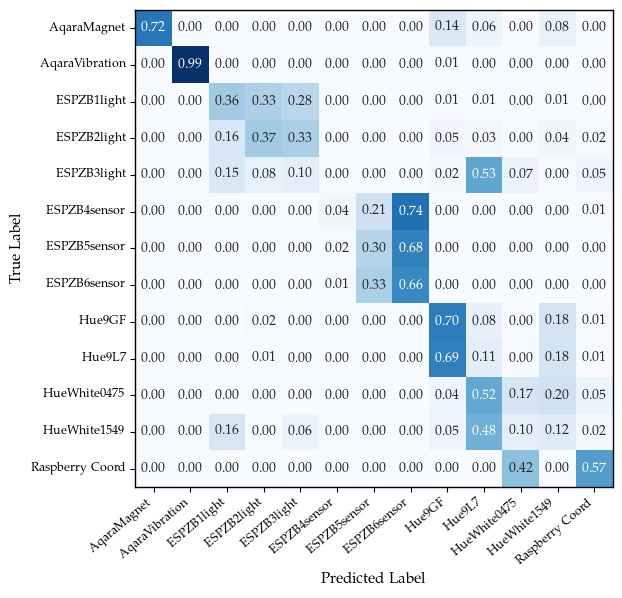

In [74]:
print_cm(train="C", test="AB", protocol="ZB")

## Train AB, Test C

### Matter over Thread

In [75]:
classify(train="AB", test="C", protocol="MT")

                precision    recall  f1-score   support

     AqaraDoor       0.72      0.88      0.79      2052
   AqaraMotion       0.89      0.74      0.81      2888
     ESP1light       0.03      0.25      0.05      5031
     ESP2light       0.02      0.00      0.00     43202
     ESP3light       0.37      0.32      0.34      5627
    ESP4sensor       0.50      0.59      0.54      4486
    ESP5sensor       0.47      0.49      0.48      4944
    ESP6sensor       0.42      0.33      0.37      5143
  HueWhite0475       0.38      0.29      0.33      4390
  HueWhite1549       0.36      0.26      0.30      4591
  Nanoleaf0176       0.75      0.99      0.85     43139
  Nanoleaf1624       0.89      0.66      0.76     43143
Raspberry OTBR       0.92      0.99      0.95     43197

      accuracy                           0.61    211833
     macro avg       0.52      0.52      0.51    211833
  weighted avg       0.60      0.61      0.60    211833

Weighted F1-Score: 0.5961


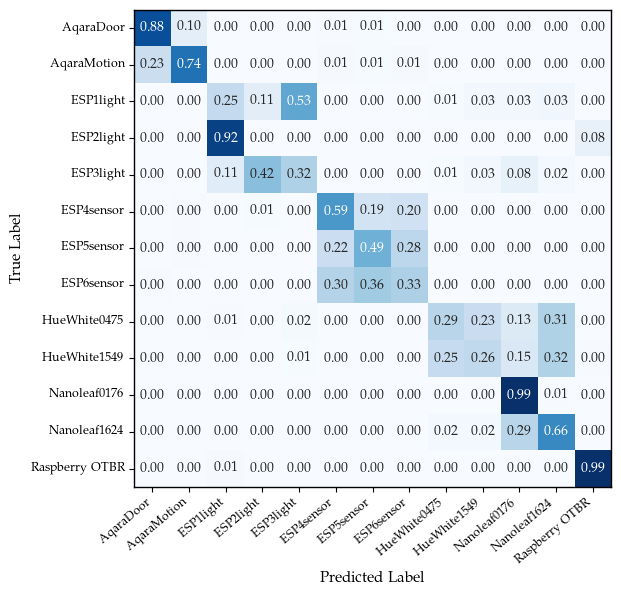

In [76]:
print_cm(train="AB", test="C", protocol="MT")

### Zigbee

In [77]:
classify(train="AB", test="C", protocol="ZB")

                 precision    recall  f1-score   support

    AqaraMagnet       0.95      0.93      0.94        76
 AqaraVibration       1.00      0.82      0.90        62
    ESPZB1light       0.39      0.76      0.51      2825
    ESPZB2light       0.29      0.24      0.26      2744
    ESPZB3light       0.04      0.11      0.06      2950
   ESPZB4sensor       0.67      0.75      0.71       219
   ESPZB5sensor       0.40      0.84      0.54       835
   ESPZB6sensor       0.37      0.07      0.12      1173
         Hue9GF       0.56      0.44      0.50      5827
         Hue9L7       0.18      0.04      0.07     17017
   HueWhite0475       0.32      0.12      0.17     42908
   HueWhite1549       0.13      0.14      0.14      5520
Raspberry Coord       0.23      0.91      0.36     10853

       accuracy                           0.25     93009
      macro avg       0.42      0.48      0.41     93009
   weighted avg       0.28      0.25      0.21     93009

Weighted F1-Score: 0.2092


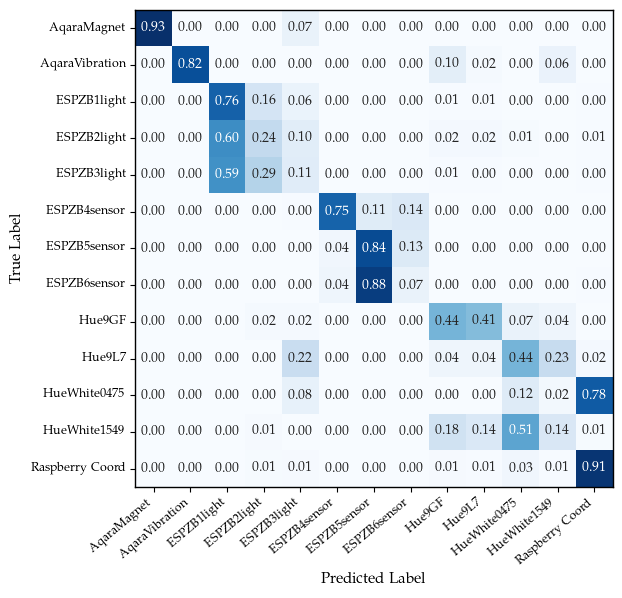

In [78]:
print_cm(train="AB", test="C", protocol="ZB")